# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model trained on chemo-only patients and recalibrates predictions using isotonic regression for patients with advanced head and neck cancer receiving first-line pembrolizumab plus chemotherapy or pembrolizumab.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
df = pd.read_csv('../outputs/gb_survival_predictions_chemo.csv')

In [3]:
df.shape

(1736, 201)

In [4]:
df = df.query('adv_diagnosis_year <= 2021')

In [5]:
df.shape

(1257, 201)

## Raw Calibration Assessment

In [6]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [7]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.00268, 0.566]",0.404789,0.345472,126,0.253886,0.428631
1,"(0.566, 0.692]",0.635178,0.483663,126,0.390214,0.568412
2,"(0.692, 0.751]",0.725399,0.638111,125,0.544605,0.717410
3,"(0.751, 0.788]",0.769501,0.640539,126,0.544311,0.714739
4,"(0.788, 0.816]",0.803518,0.742587,126,0.651919,0.809612
5,"(0.816, 0.841]",0.828727,0.811172,125,0.725728,0.867459
6,"(0.841, 0.861]",0.850990,0.805878,126,0.724452,0.865451
7,"(0.861, 0.883]",0.870971,0.917852,125,0.850809,0.953826
8,"(0.883, 0.905]",0.892948,0.925597,126,0.861844,0.960592
9,"(0.905, 0.946]",0.921377,0.950374,126,0.892846,0.977401


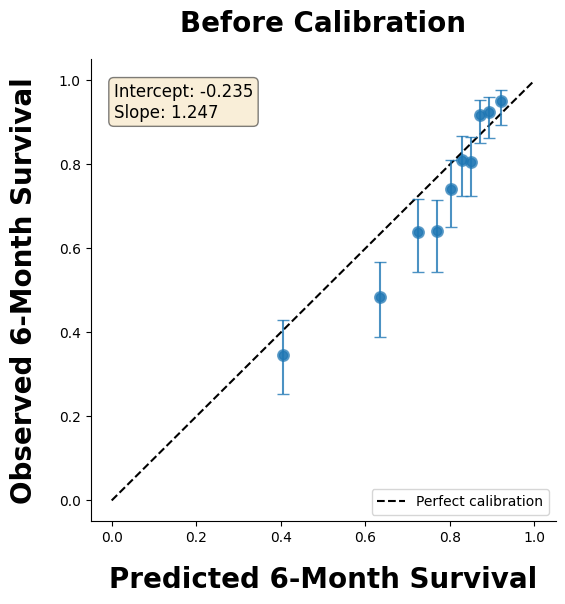

In [8]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

## Isotonic Calibration Using Cross Validation 

In [9]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [10]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1765

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1555

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1713

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1482

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1561

=== Summary ===
psurv_180_calibrated computed: 1257

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1615 ± 0.0106


In [11]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [12]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated_chemo.csv', index = False)

In [13]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [14]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.463]",0.329584,0.371515,135,0.284969,0.455372
1,"(0.463, 0.555]",0.507249,0.524079,121,0.421940,0.605578
2,"(0.555, 0.642]",0.616858,0.588651,134,0.498444,0.668099
3,"(0.642, 0.711]",0.675414,0.664001,125,0.562745,0.731466
4,"(0.711, 0.789]",0.765781,0.745176,131,0.656723,0.810712
5,"(0.789, 0.808]",0.799837,0.840584,108,0.750659,0.893893
6,"(0.808, 0.866]",0.831393,0.789809,127,0.706814,0.851748
7,"(0.866, 0.919]",0.908463,0.935654,146,0.879957,0.966000
8,"(0.919, 0.939]",0.933886,0.893165,138,0.825685,0.934986
9,"(0.939, 1.0]",0.979479,0.966786,92,0.900555,0.989166


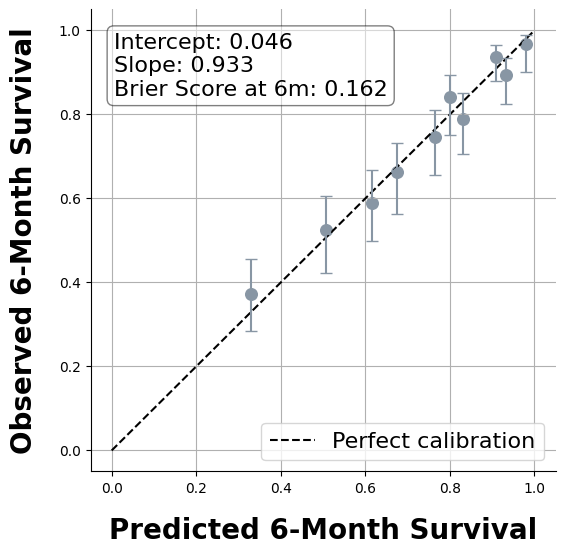

In [15]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color = '#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()